In [2]:
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import seaborn as sns
import numpy as np
import textgrid
import librosa
import librosa.display

from pathlib import Path
import re

In [3]:
sns.set_context("paper", font_scale=1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

In [4]:
plot_word = "desolate"
plot_files = list(Path("textgrids").glob(f"*_{plot_word}_*.TextGrid"))

plot_max_frequency = 8000

In [5]:
step_files = {}
for f in plot_files:
    stimulus_step = int(re.findall(r"_(\d+)$", f.stem)[0])
    step_files[stimulus_step] = f
steps = sorted(step_files.keys())

11_desolate_dn_002
11_desolate_dn_003
11_desolate_dn_004
11_desolate_dn_005
11_desolate_dn_006
11_desolate_dn_007


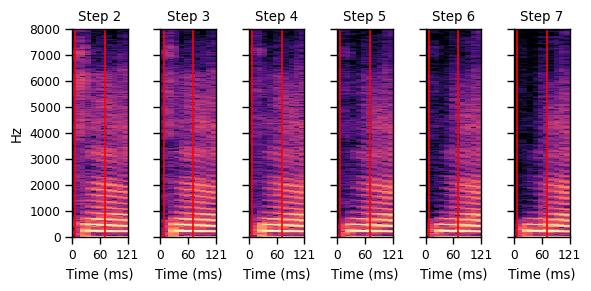

In [6]:
n_cols = 6
n_rows = int(np.ceil(len(steps) / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(1 * n_cols, 3 * n_rows), sharey=True)

interval = None

for i, (ax, step) in enumerate(zip(axs.flat, steps)):
    f = step_files[step]
    wav_path = f.with_suffix(".wav")
    audio_data, sample_rate = librosa.load(wav_path, sr=None, mono=True)

    ax.set_title(f"Step {step}")

    print(f.stem)
    stimulus_step = int(re.findall(r"_(\d+)$", f.stem)[0])

    # HACK only do this once so that it's consistent across files
    if interval is None:
        tg = textgrid.TextGrid.fromFile(f)
        tier = next(tier for tier in tg.tiers if tier.name == "phonemes")
        interval = next(interval for interval in tier.intervals if interval.mark.strip() != "")

    # STFT -> power -> dB
    hop_length = 512
    n_fft = 2048
    S = librosa.stft(audio_data, n_fft=n_fft, hop_length=hop_length)
    S = np.abs(S) ** 2
    # S = librosa.feature.melspectrogram(y=audio_data,
    #                                    sr=sample_rate,
    #                                    n_fft=n_fft,
    #                                    hop_length=hop_length,
    #                                    n_mels=80)
    S = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(S, sr=sample_rate, n_fft=n_fft, hop_length=hop_length,
                             x_axis="time", y_axis="linear", ax=ax)

    
    ax.set_ylim((0, plot_max_frequency))
    if i > 0:
        ax.set_ylabel(None)

    times = librosa.times_like(S, sr=sample_rate, hop_length=hop_length)

    # plot this much left-right time padding around the focus interval
    plot_padding = 0.05
    ax.set_xlim((max(0, interval.minTime - plot_padding), min(times[-1], interval.maxTime + plot_padding)))

    xticks = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 3, endpoint=True)
    ax.set_xticks(xticks)
    ax.set_xticklabels(["%d" % x for x in np.array(xticks) * 1000])
    ax.set_xlabel("Time (ms)")

    ax.axvline(interval.minTime, color='r')
    ax.axvline(interval.maxTime, color='r')

fig.tight_layout()

# axs.flat[0].set_title("/b/")
# axs.flat[-1].set_title("/m/")

In [7]:
step_files

{7: PosixPath('textgrids/11_desolate_dn_007.TextGrid'),
 6: PosixPath('textgrids/11_desolate_dn_006.TextGrid'),
 5: PosixPath('textgrids/11_desolate_dn_005.TextGrid'),
 2: PosixPath('textgrids/11_desolate_dn_002.TextGrid'),
 4: PosixPath('textgrids/11_desolate_dn_004.TextGrid'),
 3: PosixPath('textgrids/11_desolate_dn_003.TextGrid')}

In [8]:
!soxi textgrids/11_desolate_dn_002.wav


Input File     : 'textgrids/11_desolate_dn_002.wav'
Channels       : 1
Sample Rate    : 44100
Precision      : 16-bit
Duration       : 00:00:01.00 = 43883 samples = 74.631 CDDA sectors
File Size      : 87.8k
Bit Rate       : 706k
Sample Encoding: 16-bit Signed Integer PCM



In [9]:
!soxi textgrids/11_necessary_dn_002.wav


Input File     : 'textgrids/11_necessary_dn_002.wav'
Channels       : 1
Sample Rate    : 44100
Precision      : 16-bit
Duration       : 00:00:01.37 = 60220 samples = 102.415 CDDA sectors
File Size      : 120k
Bit Rate       : 706k
Sample Encoding: 16-bit Signed Integer PCM



In [10]:
step_files

{7: PosixPath('textgrids/11_desolate_dn_007.TextGrid'),
 6: PosixPath('textgrids/11_desolate_dn_006.TextGrid'),
 5: PosixPath('textgrids/11_desolate_dn_005.TextGrid'),
 2: PosixPath('textgrids/11_desolate_dn_002.TextGrid'),
 4: PosixPath('textgrids/11_desolate_dn_004.TextGrid'),
 3: PosixPath('textgrids/11_desolate_dn_003.TextGrid')}

(-0.4278533935546875, 0.9631927490234375)


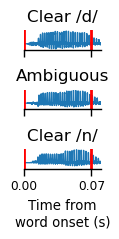

In [39]:
plot_steps = [1, 3, 6]
plot_labels = ["Clear /d/", "Ambiguous", "Clear /n/"]
n_rows = len(plot_steps)
waveform_height = 0.6

fig, axs = plt.subplots(n_rows, 1,
                        figsize=(1, waveform_height * n_rows),
                        sharex=True)

# Handle case where there's only one step
if n_rows == 1:
    axs = [axs]

interval = None
audio_data = {}

for i, (ax, step) in enumerate(zip(axs, plot_steps)):
    file = step_files[step + 1]
    stimulus_step = int(re.findall(r"_(\d+)$", file.stem)[0]) - 1
    wav_path = file.with_suffix(".wav")

    audio_data[stimulus_step], sample_rate = \
        librosa.load(wav_path, sr=44100, mono=True)

    # HACK only do this once so that it's consistent across files
    if interval is None:
        tg = textgrid.TextGrid.fromFile(file)
        tier = next(tier for tier in tg.tiers if tier.name == "phonemes")
        interval = next(interval for interval in tier.intervals if interval.mark.strip() != "")

    min_time = np.round(interval.minTime, 2)
    max_time = np.round(interval.maxTime, 2)

    # Get time array for the audio
    times = librosa.times_like(audio_data[stimulus_step], sr=sample_rate) / 1000  # convert to seconds
    
    # Plot waveform horizontally
    ax.plot(times, audio_data[stimulus_step], linewidth=1)
    
    # Set limits with padding
    plot_padding = 0.01  # seconds
    ax.set_xlim((max(0, min_time - plot_padding), 
                 max_time + plot_padding))
    
    # Configure x-axis (time)
    # xticks = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 3, endpoint=True)
    # ax.set_xticks(xticks)
    # ax.set_xticklabels(["%d" % x for x in np.array(xticks)])
    ax.set_xticks([0, max_time])
    
    ax.set_yticks([])
    # Add step label on the left
    ax.set_title(plot_labels[i], loc='center', fontsize=12)
    # ax.set_ylabel(f"Step {stimulus_step}", rotation=0, ha='right', va='center')
    
    # Add interval markers
    ax.axvline(0, color='r', linewidth=2)
    ax.axvline(max_time, color='r', linewidth=2)

    # despine
    sns.despine(ax=ax, left=True)

# Only bottom plot gets x-label
axs[-1].set_xlabel("Time from\nword onset (s)")
print(axs[0].get_ylim())

# fig.tight_layout()
fig.subplots_adjust(hspace=2)

In [30]:
alternative, _ = librosa.load("textgrids/11_necessary_dn_002.wav", sr=44100, mono=True)

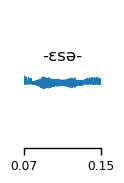

In [31]:
# indices of matched region [inclusive, exclusive) in phonemes
matched_region_start, matched_region_end = (2, 5)

f, axs = plt.subplots(n_rows, 1, figsize=(1, waveform_height * n_rows))
for ax in axs:
    sns.despine(ax=ax, left=True, right=True, top=True, bottom=True)
    ax.set_xticks([])
    ax.set_yticks([])

ax = axs[1]
ax.plot(librosa.times_like(audio_data[1], sr=sample_rate) / 1000,
         audio_data[1])
# ax.plot(librosa.times_like(alternative, sr=sample_rate),
#          alternative, alpha=0.2)

min_time_label = 0.070
max_time_label = 0.150
ax.set_xlim((min_time_label, max_time_label))
ax.set_title("-ɛsə-", fontsize=12)#, fontweight='bold')

ax.set_yticks([])
# plt.plot(librosa.times_like(audio_data[3], sr=sample_rate),
#          audio_data[3], alpha=0.2)
# plt.plot(librosa.times_like(audio_data[6], sr=sample_rate),
#          audio_data[6], alpha=0.2)

axs[-1].set_xlim((min_time_label, max_time_label))
axs[-1].set_xticks([min_time_label, max_time_label])
axs[-1].spines['bottom'].set_visible(True)

f.subplots_adjust(hspace=2)

In [14]:
tier.intervals

[Interval(0.0, 0.00693, None),
 Interval(0.00693, 0.0716, d),
 Interval(0.0716, 0.15416, e),
 Interval(0.15416, 0.25667, s),
 Interval(0.25667, 0.29726, ə),
 Interval(0.29726, 0.39961, l),
 Interval(0.39961, 0.46238, ə),
 Interval(0.46238, 0.49799, t),
 Interval(0.49799, 1.00512, None)]

(0.060000000000000005, 0.31)

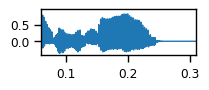

In [36]:
f, ax = plt.subplots(figsize=(2, waveform_height))

# use the previously loaded audio_data to plot
times = librosa.times_like(audio_data[1], sr=sample_rate) / 1000
ax.plot(times, audio_data[1], linewidth=1)

min_time = np.round(tier.intervals[matched_region_start].minTime, 2)
max_time = np.round(tier.intervals[matched_region_end - 1].maxTime, 2)

plot_padding = 0.01
ax.set_xlim((max(0, min_time - plot_padding), 
             max_time + plot_padding))


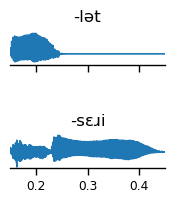

In [38]:
div_region_start = 5

f, axs = plt.subplots(2, figsize=(2, waveform_height * 3))

min_time = 0.150
max_time = 0.450

axs[0].plot(librosa.times_like(audio_data[1], sr=sample_rate) / 1000,
            audio_data[1])
axs[0].set_xlim((min_time, max_time))
axs[0].set_title("-lət", fontsize=12)#, fontweight='bold')
axs[0].set_xticklabels([])

axs[1].plot(librosa.times_like(alternative, sr=sample_rate) / 1000,
            alternative)
axs[1].set_xlim((min_time, max_time))
axs[1].set_title("-sɛɹi", fontsize=12)#, fontweight='bold')

for ax in axs:
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

f.subplots_adjust(hspace=2)

In [17]:
n_cols = 3
n_rows = int(np.ceil(len(specs) / n_cols))

f, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

steps = sorted(specs.keys())
for ax, step in zip(axs.flat, steps):
    freqs, times, spectrogram_data = specs[step]
    ax.pcolormesh(times, freqs, np.log(spectrogram_data + 1e-10), cmap="RdBu")
    ax.set_title(f"Stimulus step {step}")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_xlabel("Time [sec]")
    # ax.set_ylim(0, 8000)

NameError: name 'specs' is not defined

In [ ]:
plt.pcolormesh(times, freqs, np.log(spectrogram_data))

NameError: name 'freqs' is not defined